# ViT

FashionMNIST 다운로드

In [ ]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

print(f"Training Data Size : {len(subset_train_dataset)}")
print(f"Testing Data Size : {len(subset_test_dataset)}")
print(train_dataset[0])

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 178kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.8MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Training Data Size : 10000
Testing Data Size : 1000
(<PIL.Image.Image image mode=L size=28x28 at 0x7C8B2FC39340>, 9)


이미지 전처리
- AutoImageProcessor: 사전 학습된 ViT모델로 전처리 진행
- 모델 입력: {"pixel_values":pixel_values, "labels":labels}
- -> 데이터로더에 collate_fn 적용해 미니 배치의 샘플 목록 병합

In [ ]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor


image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

print(f"size: {image_processor.size}")
print(f"mean: {image_processor.image_mean}")
print(f"std: {image_processor.image_std}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


size: {'height': 224, 'width': 224}
mean: [0.5, 0.5, 0.5]
std: [0.5, 0.5, 0.5]


ViT 데이터로더 적용

In [ ]:
from torch.utils.data import DataLoader


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

batch = next(iter(train_dataloader))
for key, value in batch.items():
    print(f"{key} : {value.shape}")

pixel_values : torch.Size([32, 3, 224, 224])
labels : torch.Size([32])


사전 학습된 ViT 모델
- 레이블 개수, ID/레이블, 레이블/ID 매개변수로 모델 미세 조정

In [ ]:
from transformers import ViTForImageClassification


model = ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
    num_labels=len(classes),
    id2label={idx: label for label, idx in class_to_idx.items()},
    label2id=class_to_idx,
    ignore_mismatched_sizes=True
)

print(model.classifier)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=10, bias=True)


패치 임베딩 확인

In [ ]:
print(model.vit.embeddings)

batch = next(iter(train_dataloader))
print("image shape :", batch["pixel_values"].shape)
print("patch embeddings shape :",
    model.vit.embeddings.patch_embeddings(batch["pixel_values"]).shape
)
print("[CLS] + patch embeddings shape :",
    model.vit.embeddings(batch["pixel_values"]).shape
)

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
image shape : torch.Size([32, 3, 224, 224])
patch embeddings shape : torch.Size([32, 196, 768])
[CLS] + patch embeddings shape : torch.Size([32, 197, 768])


In [ ]:
!pip install -U transformers

하이퍼파라미터 설정
- 학습 매개변수 클래스 (TrainingArguments)

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00


매크로 평균 F1 점수
- 모든 클래스에 대한 F1 점수의 가중 평균

load(메트릭 불러오기 함수)
- acuracy, precision, f1....

eval_pred 인수
- 모델이 예측한 결괏값 전달받음
- 가장 확률이 높은 값 prediction 변수에 저장

In [ ]:
import evaluate
import numpy as np


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

ViT 모델 학습

Trainer 클래스를 통해 ViT 모델 학습
- model_init 형태로 모델 생성해 전달
- 데이터로더가 내부적으로 수행됨

tokenizer
- image_processor 전달

In [ ]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = ViTForImageClassification.from_pretrained(
        pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=200
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-671823266.py:104: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
Yo

Epoch,Training Loss,Validation Loss,F1
1,1.739000,1.692459,0.770984


TrainOutput(global_step=250, training_loss=1.9057001953125, metrics={'train_runtime': 88.6964, 'train_samples_per_second': 22.549, 'train_steps_per_second': 2.819, 'total_flos': 1.54995091808256e+17, 'train_loss': 1.9057001953125, 'epoch': 1.0})

ViT 모델 성능 평가

혼돈 행렬(Confusion Matrix)로 예측 결과 확인

PredictionOutput(predictions=array([[ 5.94802022e-01, -2.32288033e-01,  1.76849216e-01, ...,
        -2.33521834e-01, -1.01604946e-01, -3.25207144e-01],
       [ 2.67378956e-01, -1.34597823e-01,  5.30142933e-02, ...,
        -1.80839092e-01, -9.78076607e-02, -2.62574166e-01],
       [ 3.87727022e-01, -3.39717150e-01,  2.54697651e-01, ...,
        -2.72010654e-01,  8.27802271e-02, -1.74144611e-01],
       ...,
       [-1.93678066e-01, -2.11798504e-01, -1.43799230e-01, ...,
         5.67653716e-01,  2.79593915e-01,  5.83228290e-01],
       [-2.72777647e-01, -1.63579211e-01, -1.15434796e-01, ...,
         5.83230376e-01,  8.97324830e-02,  1.02773643e+00],
       [-1.12311244e-01, -1.00046173e-01,  9.69810877e-04, ...,
         2.23944247e-01, -4.08996083e-02,  9.10285592e-01]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

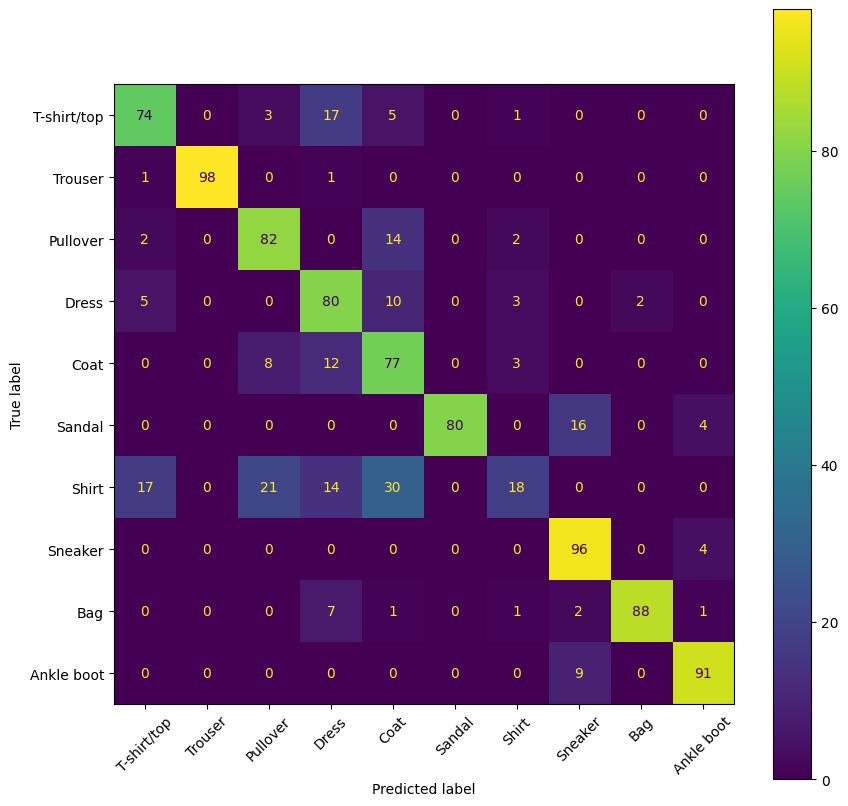

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

# 스윈 트랜스포머

상대적 위치 편향 계산

window_size
- 여러개의 이미지 패치를 포함하는 격자의 크기
- 윈도 내외부의 패치 구분

torch.meshgrid 함수
- corrd_h와 coords_w값으로 사각형 격자 만듦

- torch.stack -> (X, Y) 배열 생성
- torch.flatten으로 coords_flatten 생성
- 각 위치 색인의 차이 계산

In [ ]:
import torch


window_size = 2
coords_h = torch.arange(window_size)
coords_w = torch.arange(window_size)
coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))
coords_flatten = torch.flatten(coords, 1)
relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]

print(relative_coords)
print(relative_coords.shape)

tensor([[[ 0,  0, -1, -1],
         [ 0,  0, -1, -1],
         [ 1,  1,  0,  0],
         [ 1,  1,  0,  0]],

        [[ 0, -1,  0, -1],
         [ 1,  0,  1,  0],
         [ 0, -1,  0, -1],
         [ 1,  0,  1,  0]]])
torch.Size([2, 4, 4])


X, Y축에 대한 위치 행렬

In [ ]:
x_coords = relative_coords[0, :, :]
y_coords = relative_coords[1, :, :]

x_coords += window_size - 1
y_coords += window_size - 1
x_coords *= 2 * window_size - 1
print(f"X축에 대한 행렬: \n{x_coords}\n")
print(f"Y축에 대한 행렬: \n{y_coords}\n")

relative_position_index = x_coords + y_coords
print(f"X, Y축에 대한 위치 행렬: \n{relative_position_index}")

X축에 대한 행렬: 
tensor([[3, 3, 0, 0],
        [3, 3, 0, 0],
        [6, 6, 3, 3],
        [6, 6, 3, 3]])

Y축에 대한 행렬: 
tensor([[1, 0, 1, 0],
        [2, 1, 2, 1],
        [1, 0, 1, 0],
        [2, 1, 2, 1]])

X, Y축에 대한 위치 행렬: 
tensor([[4, 3, 1, 0],
        [5, 4, 2, 1],
        [7, 6, 4, 3],
        [8, 7, 5, 4]])


X, Y축에 대한 상대적 위치 좌표 변환

In [ ]:
num_heads = 1
relative_position_bias_table = torch.Tensor(
    torch.zeros((2 * window_size - 1) * (2 * window_size - 1), num_heads)
)

relative_position_bias = relative_position_bias_table[relative_position_index.view(-1)]
relative_position_bias = relative_position_bias.view(
    window_size * window_size, window_size * window_size, -1
)
print(relative_position_bias.shape)

torch.Size([4, 4, 1])


# 스윈 트랜스포머 실습

사전 학습된 스윈 트랜스포머 모델

스윈 트랜스포머 : swin/ classifier

패치 파티션, 선형 임베딩 - model.swin.embeddings.patch_embeddings에서

In [ ]:
from transformers import SwinForImageClassification


model = SwinForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("ㄴ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  ㄴ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                if sssub_name == "projection":
                    print("│  │  ㄴ", sssub_name, sssub_module)
                else:
                    print("│  │  ㄴ", sssub_name)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


swin
ㄴ embeddings
│  ㄴ patch_embeddings
│  │  ㄴ projection Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
│  ㄴ norm
│  ㄴ dropout
ㄴ encoder
│  ㄴ layers
│  │  ㄴ 0
│  │  ㄴ 1
│  │  ㄴ 2
│  │  ㄴ 3
ㄴ layernorm
ㄴ pooler
classifier


패치 임베딩 모듈

In [ ]:
batch = next(iter(train_dataloader))
print("이미지 차원:", batch["pixel_values"].shape)

patch_emb_output, shape = model.swin.embeddings.patch_embeddings(batch["pixel_values"])
print("모듈: ", model.swin.embeddings.patch_embeddings)
print("패치 임베딩 차원:", patch_emb_output.shape)

이미지 차원: torch.Size([32, 3, 224, 224])
모듈:  SwinPatchEmbeddings(
  (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
)
패치 임베딩 차원: torch.Size([32, 3136, 96])


스윈 트랜스포머 블록

첫 번째 스테이지의 스윈 트랜스포머 출력

스윈 트랜스포머의 스테이지: blocks/downsample

blocks: 스윈 트랜스포머 블록

downsample: 패치 병합

In [ ]:
for main_name, main_module in model.swin.encoder.layers[0].named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("ㄴ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│ ㄴ", ssub_name)

blocks
ㄴ 0
│ ㄴ layernorm_before
│ ㄴ attention
│ ㄴ drop_path
│ ㄴ layernorm_after
│ ㄴ intermediate
│ ㄴ output
ㄴ 1
│ ㄴ layernorm_before
│ ㄴ attention
│ ㄴ drop_path
│ ㄴ layernorm_after
│ ㄴ intermediate
│ ㄴ output
downsample
ㄴ reduction
ㄴ norm


SwinLayer 구조

스윈 트랜스포머 블록
- 정규화 -> W-MSA -> 계층 정규화 -> MLP


- layernorm_before: 첫 번째 정규화
- attnetion: W-MSA
- layernorm_after: 두 번째 계층 정규화
- intermediate, output: MLP

GELU
- ReLU와 유사한 형태
- 가우시안 분포에 대한 누적 분포 함수
- 입력 특징맵을 더 깊은 차원으로 매핑, ReLU 사용했을 때보다 안정적으로 학습

In [ ]:
print(model.swin.encoder.layers[0].blocks[0])

SwinLayer(
  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (attention): SwinAttention(
    (self): SwinSelfAttention(
      (query): Linear(in_features=96, out_features=96, bias=True)
      (key): Linear(in_features=96, out_features=96, bias=True)
      (value): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): SwinSelfOutput(
      (dense): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (drop_path): Identity()
  (layernorm_after): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (intermediate): SwinIntermediate(
    (dense): Linear(in_features=96, out_features=384, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): SwinOutput(
    (dense): Linear(in_features=384, out_features=96, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)


W-MSA, SW-MSA 모듈

In [ ]:

print("패치 임베딩 차원:", patch_emb_output.shape)

W_MSA = model.swin.encoder.layers[0].blocks[0]
SW_MSA = model.swin.encoder.layers[0].blocks[1]

W_MSA_output = W_MSA(patch_emb_output, W_MSA.input_resolution)[0]
SW_MSA_output = SW_MSA(W_MSA_output, SW_MSA.input_resolution)[0]

print("W-MSA 결과차원:", W_MSA_output.shape)
print("SW-MSA 결과차원:", SW_MSA_output.shape)

패치 임베딩 차원: torch.Size([32, 3136, 96])
W-MSA 결과차원: torch.Size([32, 3136, 96])
SW-MSA 결과차원: torch.Size([32, 3136, 96])


패치 병합
- reduction, 계층 정규화
- 패치 병합 과정으로 56x56 -> 28x28
- (N, 28, 28, 96) 텐서 생성
- patch_merge 결과: [N, 784, 192]
- 마지막 스테이지 후 [N, 49, 768]

In [ ]:
patch_merge = model.swin.encoder.layers[0].downsample
print("patch_merge 모듈:", patch_merge)

output = patch_merge(SW_MSA_output, patch_merge.input_resolution)
print("patch_merge 결과차원:", output.shape)

patch_merge 모듈: SwinPatchMerging(
  (reduction): Linear(in_features=384, out_features=192, bias=False)
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)
patch_merge 결과차원: torch.Size([32, 784, 192])


스윈 트랜스포머 모델 학습

In [ ]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import SwinForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = SwinForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=200
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=50
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
                )
            ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/Swin-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    fp16=True
)


trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-994979115.py:110: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instan

Epoch,Training Loss,Validation Loss,F1
1,1.501600,0.974411,0.753707


TrainOutput(global_step=125, training_loss=1.5016290283203124, metrics={'train_runtime': 22.7456, 'train_samples_per_second': 87.929, 'train_steps_per_second': 5.496, 'total_flos': 4.9723090550784e+16, 'train_loss': 1.5016290283203124, 'epoch': 1.0})

PredictionOutput(predictions=array([[ 2.9960938 , -1.0800781 , -0.18835449, ..., -1.1357422 ,
        -1.0039062 , -0.31274414],
       [ 1.3916016 ,  0.82958984,  0.6254883 , ..., -0.9633789 ,
        -0.21154785, -0.72998047],
       [ 1.3701172 , -0.32495117, -0.56591797, ..., -0.27368164,
         0.09301758, -0.87402344],
       ...,
       [-0.02246094, -0.08166504,  0.16589355, ..., -0.11364746,
         0.09527588,  2.1972656 ],
       [-1.0019531 , -1.328125  , -1.1962891 , ...,  1.9179688 ,
        -0.06604004,  2.2441406 ],
       [-0.05215454, -0.09008789, -0.12695312, ...,  0.45581055,
         0.7402344 ,  2.515625  ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

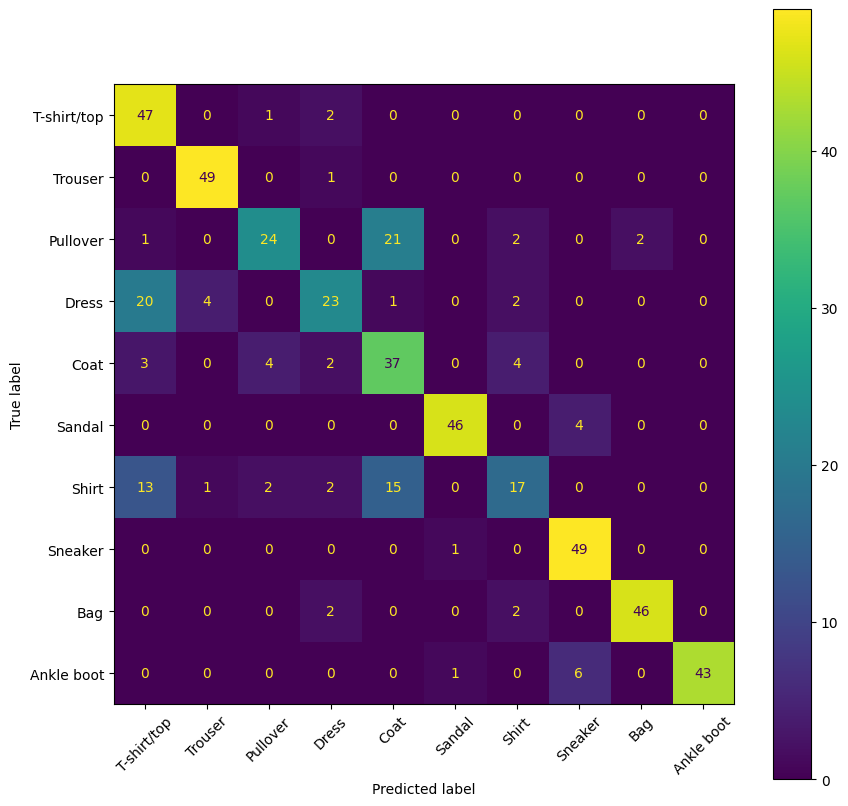

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

# CvT

CvT 모델 이미지 데이터 전처리
- shortest_edge 키 사용
- 이미지의 너비나 높이 중 더 작은 값

In [ ]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor


image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["shortest_edge"],
                image_processor.size["shortest_edge"]
            )
        ),
        transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

사전 학습된 CvT 모델
- 차이점: classifier DLWJSDP pooler 계층 존재 X
- 이미 합성곱 계층 활용해 지역 특징 정보와 전역 정보 파악

In [ ]:
from transformers import CvtForImageClassification


model = CvtForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("ㄴ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("   ㄴ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("     ㄴ", sssub_name)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


cvt
ㄴ encoder
   ㄴ stages
     ㄴ 0
     ㄴ 1
     ㄴ 2
layernorm
classifier


CvT 모델의 스테이지 구조

각 스테이지: CvTEmbeddings/CvtLayer로 구성
- CvTEmbeddings: 입력 이미지에 대한 2D 합성곱 연산과 계층 정규화
- 이미지를 패치 단위로 잘라 임베딩하는 역할

In [ ]:
stages = model.cvt.encoder.stages
print(stages[0])

CvtStage(
  (embedding): CvtEmbeddings(
    (convolution_embeddings): CvtConvEmbeddings(
      (projection): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
      (normalization): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): Sequential(
    (0): CvtLayer(
      (attention): CvtAttention(
        (attention): CvtSelfAttention(
          (convolution_projection_query): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAttentionConvProjection(
              (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (linear_projection): CvtSelfAttentionLinearProjection()
          )
          (convolution_projection_key): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAtte

셀프 어텐션 적용

In [ ]:
batch = next(iter(train_dataloader))
print("이미지 차원:", batch["pixel_values"].shape)

patch_emb_output = stages[0].embedding(batch["pixel_values"])
print("패치 임베딩 차원:", patch_emb_output.shape)

batch_size, num_channels, height, width = patch_emb_output.shape
hidden_state = patch_emb_output.view(batch_size, num_channels, height * width).permute(0, 2, 1)
print("셀프 어텐션 입력차원:", hidden_state.shape)

attention_output = stages[0].layers[0].attention.attention(hidden_state, height, width)
print("셀프 어텐션 출력차원:", attention_output.shape)

이미지 차원: torch.Size([32, 3, 224, 224])
패치 임베딩 차원: torch.Size([32, 64, 56, 56])
셀프 어텐션 입력차원: torch.Size([32, 3136, 64])
셀프 어텐션 출력차원: torch.Size([32, 3136, 64])


CvT 모델 학습

In [ ]:
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import CvtForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = CvtForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/cvt-21",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=200
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=50
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["shortest_edge"],
                image_processor.size["shortest_edge"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/CvT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    fp16=True
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2552635661.py:105: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of CvtForImageClassification were not initialized from the model checkpoi

Epoch,Training Loss,Validation Loss,F1
1,1.701900,1.082521,0.705676


TrainOutput(global_step=125, training_loss=1.701870361328125, metrics={'train_runtime': 44.1422, 'train_samples_per_second': 45.308, 'train_steps_per_second': 2.832, 'total_flos': 5.6432729235456e+16, 'train_loss': 1.701870361328125, 'epoch': 1.0})

PredictionOutput(predictions=array([[ 2.2851562 , -0.35668945, -0.4038086 , ..., -1.3310547 ,
         0.5258789 , -1.0703125 ],
       [ 0.20153809,  0.8569336 , -0.3017578 , ..., -0.81591797,
        -0.27514648, -1.7783203 ],
       [ 1.0019531 , -0.84521484,  0.35717773, ..., -1.0771484 ,
        -0.4309082 , -1.078125  ],
       ...,
       [ 0.1505127 , -0.3774414 , -0.9707031 , ...,  0.05099487,
        -0.17773438,  1.8466797 ],
       [-0.45654297, -0.78027344, -0.71240234, ...,  2.2753906 ,
         0.4645996 ,  2.7714844 ],
       [-0.10656738, -0.2529297 , -0.27124023, ...,  0.02394104,
        -0.91308594,  1.125     ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

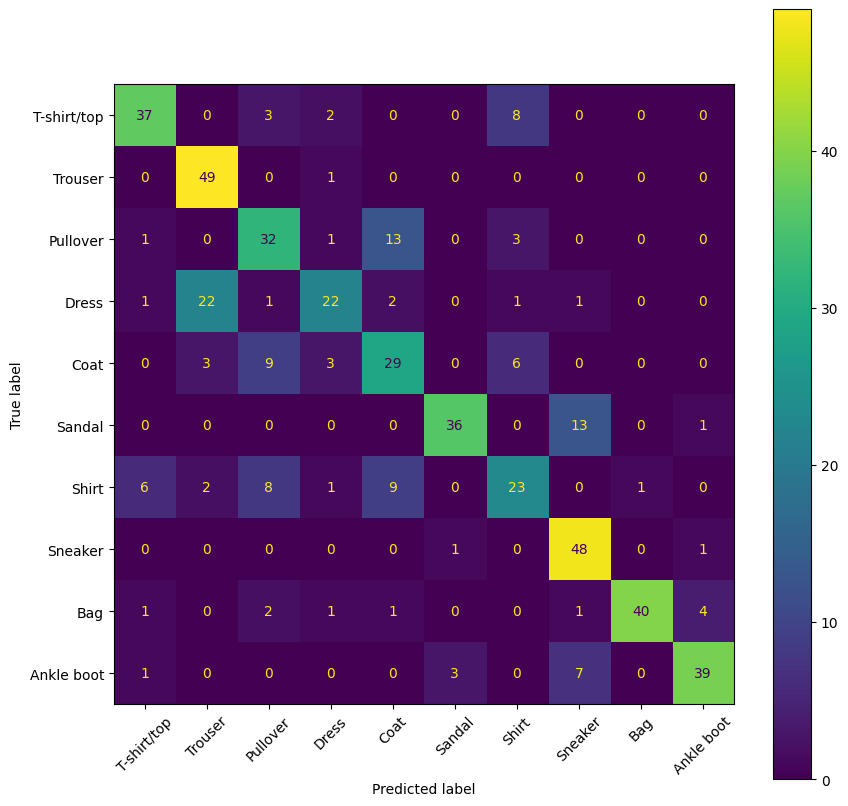

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()